In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
names = open('names.txt', 'r').read().splitlines()

In [3]:
len(names)

32033

In [4]:
chars = sorted(list(set(''.join(names))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)
print(stoi)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}


In [5]:
# build the dataset
block_size = 4 # context length: how many characters do we take to predict the next one?

def build_dataset(words):
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(names)
n1 = int(0.8*len(names))
n2 = int(0.9*len(names))

Xtrain, Ytrain = build_dataset(names[:n1])
Xval, Xval = build_dataset(names[n1:n2])
Xtest, Ytest = build_dataset(names[n2:])

torch.Size([182625, 4]) torch.Size([182625])
torch.Size([22655, 4]) torch.Size([22655])
torch.Size([22866, 4]) torch.Size([22866])


In [6]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,10), generator = g)
W1 = torch.randn((block_size * C.shape[1],200), generator = g)
b1 = torch.randn((200), generator = g)
W2 = torch.randn((200,27), generator = g)
b2 = torch.randn((27), generator = g)
parameters = [C,W1,b1,W2,b2]

for p in parameters:
    p.requires_grad=True

In [7]:
# #CURRENT CONFIG: whole set of data being used in training the neural network

# for _ in range(100):
#     #FORWARD PASS
#     embed = C[Xtrain] #embed values in X to C
#     h = torch.tanh(embed.view(embed.shape[0],6) @ W1 + b1)
#     logits = h @ W2 + b2
#     loss = F.cross_entropy(logits,Ytrain) #essentially the same as getting counts, probs, loss. 
#     # less intermediate tensors, clustering of operations are made for efficiency. both for forward and backward pass.
#     #BACKWARD PASS
#     for p in parameters:
#         p.grad = None
    
#     loss.backward()
#     for p in parameters:
#         p.data += -0.1*p.grad
#     print(loss.item())


In [8]:
lre = torch.linspace(-3,0,1000)
learning_rates = 10**lre

In [9]:
C.shape

torch.Size([27, 10])

In [10]:
#CURRENT CONFIG: batch training with variable learning rate
steps = []
loss_i = []
for i in range(250000):
    #batch size of 64
    ix = torch.randint(0,Xtrain.shape[0],(64,))
    
    #FORWARD PASS
    embed2 = C[Xtrain[ix]] #embed values in X to C (32, 3, 2)
    h2 = torch.tanh(embed2.view(embed2.shape[0],block_size * C.shape[1]) @ W1 + b1) 
    logits2 = h2 @ W2 + b2
    loss2 = F.cross_entropy(logits2,Ytrain[ix]) #essentially the same as getting counts, probs, loss. 
    # less intermediate tensors, clustering of operations are made for efficiency. both for forward and backward pass.
    
    #BACKWARD PASS
    for p in parameters:
        p.grad = None
    
    loss2.backward()
    # learningrate = learning_rates[i]
    if (i < 150000):
        learningrate = 0.1
    elif (i < 200000):
        learningrate = 0.05
    else:
        learningrate = 0.01
    for p in parameters:
        p.data += -learningrate*p.grad
    # loss_i.append(loss2.item())
    steps.append(i)
    loss_i.append(loss2.log10().item())




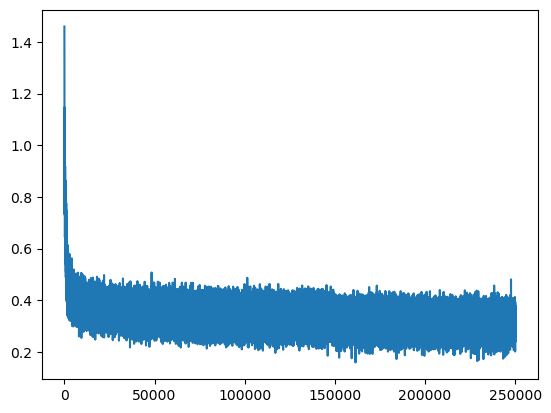

In [11]:
plt.plot(steps, loss_i)

In [12]:
loss2

tensor(1.9064, grad_fn=<NllLossBackward0>)

In [13]:
# validation loss
embed_dev = C[Xval]
h = torch.tanh(embed_dev.view(Xval.shape[0], block_size * C.shape[1]) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Yval)
loss

RuntimeError: shape '[22655, 40]' is invalid for input of size 226550

In [14]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(25):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

carmah.
ameriq.
khitgin.
reety.
skanden.
jazhnen.
delsara.
kaqui.
nelaniah.
maiir.
kaleigh.
hamondin.
quintes.
livea.
jadii.
water.
giearyn.
kakhen.
dusan.
edde.
iia.
gian.
jassia.
aras.
belanisya.
